# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [ ]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [2]:
!uv pip install -U exca

Using Python 3.12.13 environment at: /usr
Resolved 11 packages in 754ms
Prepared 5 packages in 466ms
Uninstalled 3 packages in 73ms
Installed 5 packages in 41ms
 + exca==0.5.22
 - numpy==2.0.2
 + numpy==2.4.4
 - pydantic==2.12.3
 + pydantic==2.13.2
 - pydantic-core==2.41.4
 + pydantic-core==2.46.2
 + submitit==1.5.4


In [4]:
import sys
!{sys.executable} -m pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"
!{sys.executable} -m pip install -U exca

  Cloning https://github.com/facebookresearch/tribev2.git to /tmp/pip-install-o9s7yrkw/tribev2_8b317a57bb874aa2810cded53a029d15
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/tribev2.git /tmp/pip-install-o9s7yrkw/tribev2_8b317a57bb874aa2810cded53a029d15
  Resolved https://github.com/facebookresearch/tribev2.git to commit 72399081ed3f1040c4d996cefb2864a4c46f5b8e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a

In [1]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-19 15:55:19 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-19 15:55:27 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [2]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/sample_video.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [02:44<00:00, 164.40s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 30/30 [00:00<00:00, 100342.20it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,52.210000,cache/sample_video.wav,NaN,
1,Video,0.000000,52.210000,cache/sample_video.mp4,NaN,
2,Sentence,12.212999,2.042002,NaN,What brings you to the land of the gatekeepers?.,
3,Text,12.213000,31.490000,NaN,What brings you to the land of the gatekeepers...,
4,Word,12.213000,0.120000,NaN,What,What
5,Word,12.393000,0.280000,NaN,brings,What brings
6,Word,12.713000,0.101000,NaN,you,What brings you
7,Word,12.854000,0.100000,NaN,to,What brings you to


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [3]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[16:00:35 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-04-19 16:11:00 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
Encoding video:   0%|          | 0/104 [00:00<?, ?it/s]2026-04-19 16:11:14 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (104, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (104, 20, 1408)
Encoding video: 100%|██████████| 104/104 [28:40<00:00, 16.55s/it]
[16:39:42 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-19 16:39:42 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[16:39:42 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: 

Predictions shape: (53, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  6.34it/s]


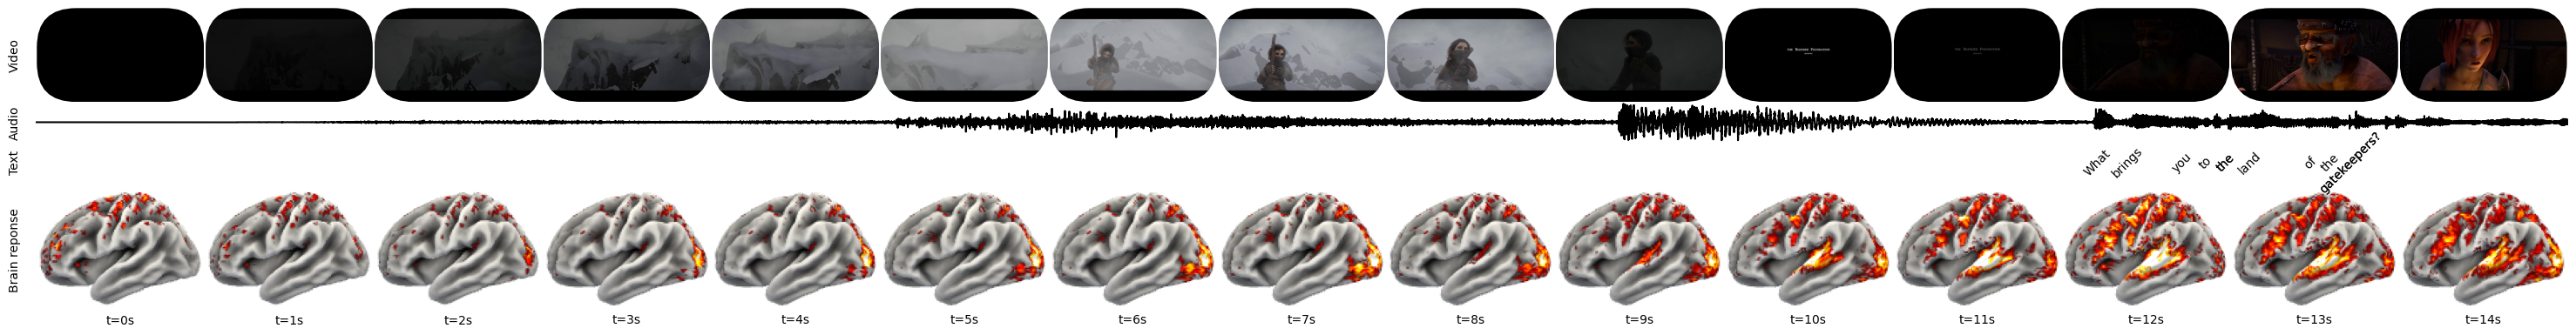

In [5]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [6]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-To-be-or-not-to-be,-that-is-the-question.-Whether-tis-nobler-in-the-mind-to-suffer-The-slings-and-arrows-of-outrageous-for...11-44470b46/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-To-be-or-not-to-be,-that-is-the-question.-Whether-tis-nobler-in-the-mind-to-suffer-The-slings-and-arrows-of-outrageous-for...11-44470b46/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [00:57<00:00, 57.22s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 60/60 [00:00<00:00, 76771.89it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,23.256000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,1.261002,NaN,To be or not to be.,
2,Text,0.091000,22.610000,NaN,To be or not to be. That is the question. Whet...,
3,Word,0.091000,0.100000,NaN,To,To
4,Word,0.271000,0.180000,NaN,be,To be
5,Word,0.551000,0.060000,NaN,or,To be or
6,Word,0.691000,0.200000,NaN,not,To be or not
7,Word,0.931000,0.100000,NaN,to,To be or not to


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [8]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[16:53:21 WARNING] Removing extractor video as there are no corresponding events
[16:53:21 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
[16:53:22 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
[16:53:22 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-19 16:53:22 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[16:53:23 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoi

Predictions shape: (24, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.03it/s]


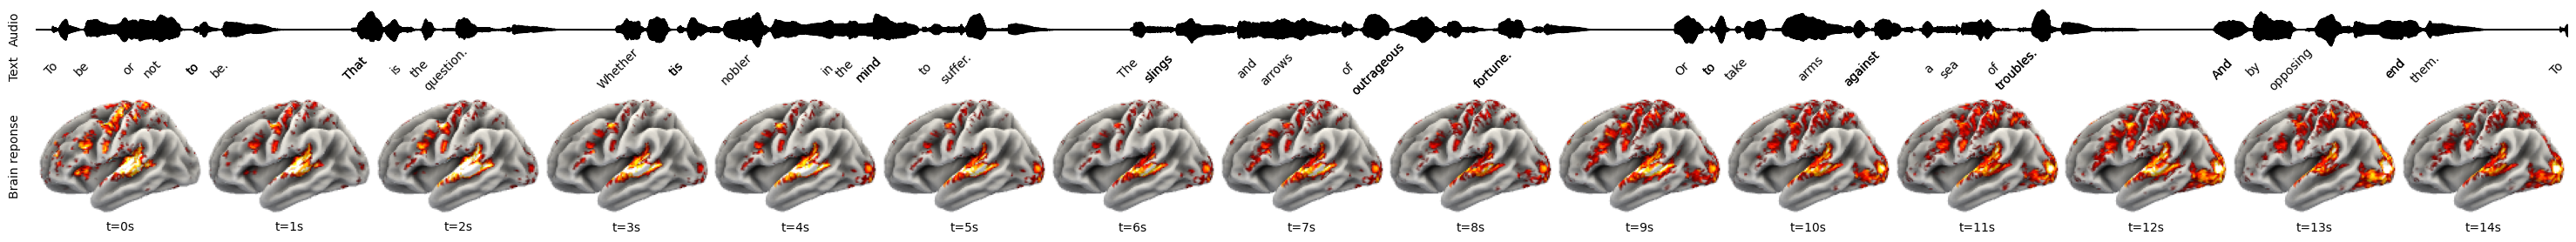

In [9]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

#Joseph Files


In [3]:
# 1. Imports + load model + plotter
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")
model = TribeModel.from_pretrained("facebook/tribev2", cache_folder=CACHE_FOLDER)
plotter = PlotBrain(mesh="fsaverage5")

# 2. Build events dataframe (video is already cached, won't re-download)
video_path = CACHE_FOLDER / "sample_video.mp4"
df = model.get_events_dataframe(video_path=video_path)

# 3. Run prediction
preds, segments = model.predict(events=df)

# 4. Make the MP4
plotter.plot_timesteps_mp4(preds[:15], "brain_activity.mp4", segments=segments[:15])

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-19 17:33:23 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-19 17:33:27 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set trea

In [4]:
# video_path = CACHE_FOLDER / "sample_video.mp4"
# url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
# download_file(url, video_path)

from google.colab import files
from pathlib import Path
import shutil

uploaded = files.upload()
filename = next(iter(uploaded))

video_path = CACHE_FOLDER / filename
shutil.move(filename, video_path)

df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

Saving What if it DOESN’T work out 😔I almost did not start this. I kept thinking, “What if this goes n.mp4 to What if it DOESN’T work out 😔I almost did not start this. I kept thinking, “What if this goes n (1).mp4


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 2626.36it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 242.96it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This 

,type,start,duration,filepath,text,context
0,Video,0.000000,10.450000,cache/What if it DOESN’T work out 😔I almost di...,NaN,
1,Audio,0.000000,10.449977,cache/What if it DOESN’T work out 😔I almost di...,NaN,
2,Sentence,9.241999,0.906002,NaN,Take it back,
3,Text,9.242000,0.906000,NaN,Take it back,
4,Word,9.242000,0.227000,NaN,Take,Take
5,Word,9.633000,0.103000,NaN,it,Take it
6,Word,9.983000,0.165000,NaN,back,Take it back


In [5]:
# Step 1: Extract the multimodal events from your video
df = model.get_events_dataframe(video_path=video_path)

# Step 2: Run brain prediction
preds, segments = model.predict(events=df)

print(f"Predictions shape: {preds.shape}")
# Output: (n_timesteps, n_vertices)
# n_timesteps = number of seconds in your video
# n_vertices = 20,000 brain surface points

Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 2554.39it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 464.43it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This 

Predictions shape: (11, 20484)


In [6]:
plotter.plot_timesteps_mp4(preds[:15], "brain_activity.mp4", segments=segments[:15])

Plotting...: 100%|██████████| 11/11 [00:22<00:00,  2.01s/it]


In [7]:
from IPython.display import Video
Video("brain_activity.mp4", embed=True)

Plotting...: 100%|██████████| 11/11 [00:02<00:00,  4.88it/s]


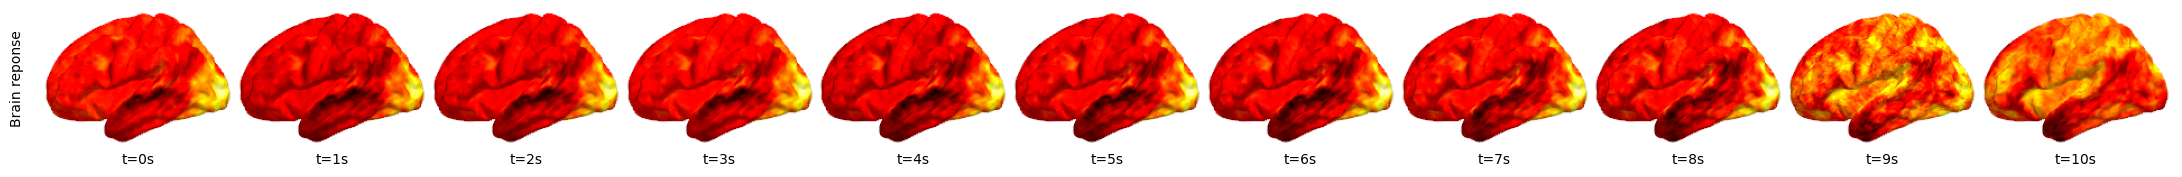

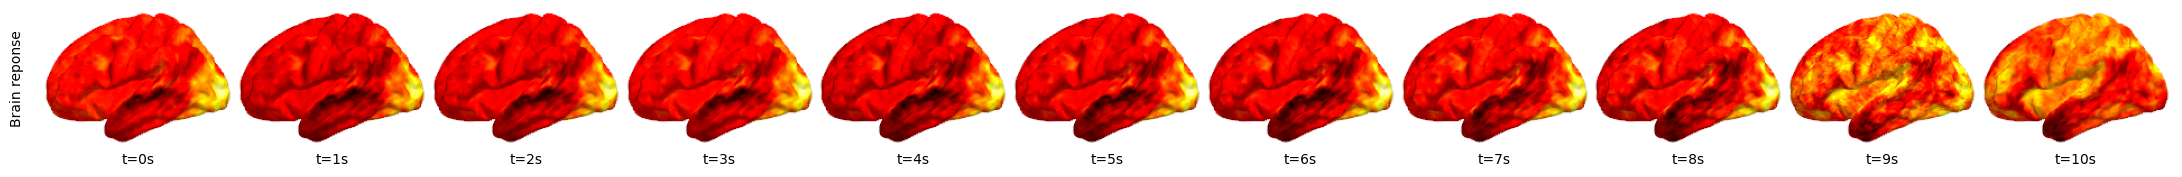

In [8]:
plotter.plot_timesteps(preds[:15], segments[:15], show_stimuli=False)

Plotting...: 100%|██████████| 11/11 [00:01<00:00,  6.30it/s]


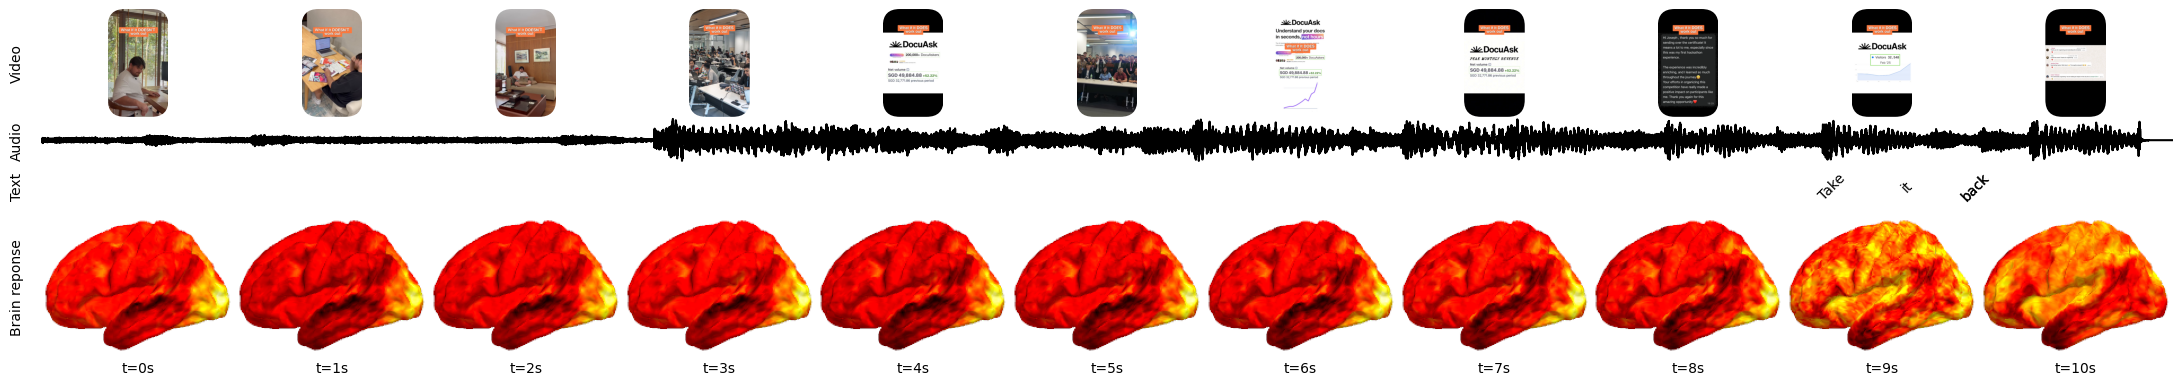

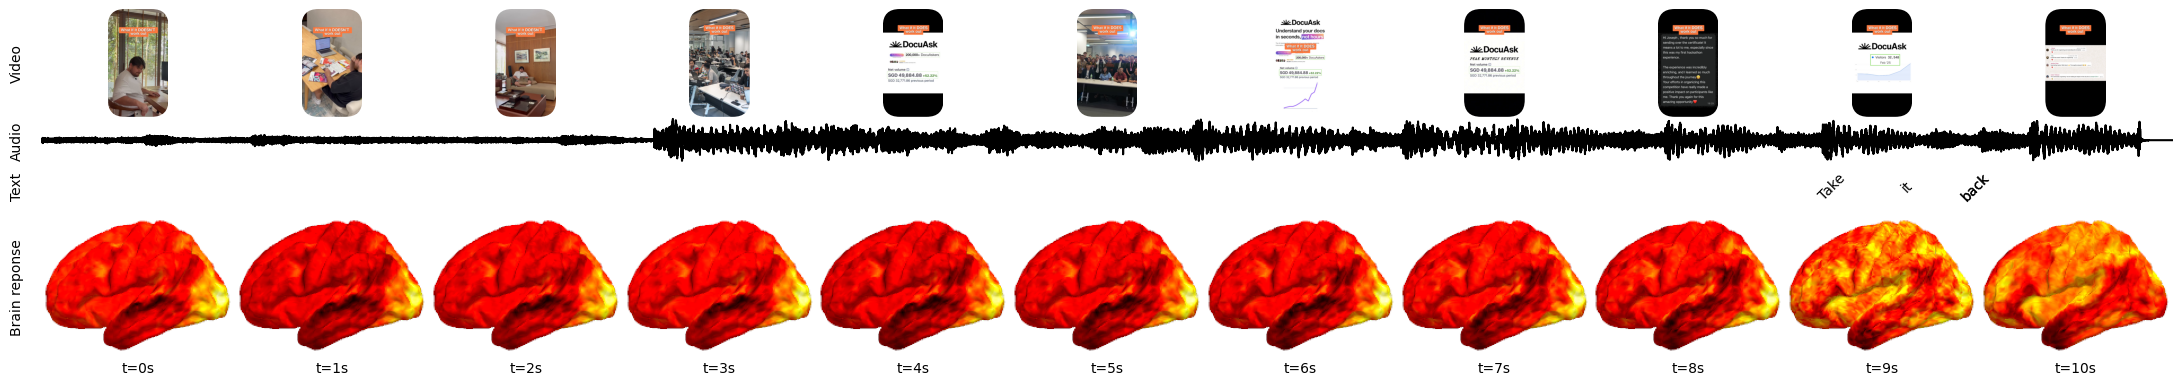

In [9]:
plotter.plot_timesteps(preds[:15], segments[:15], show_stimuli=True)

In [10]:
import numpy as np

# Get mean activation across all brain regions for each second
activation_per_second = preds.mean(axis=1)

# Get the top region activation for each second
top_region_per_second = preds.max(axis=1)

# Print a simple table
print("Second | Mean Activation | Peak Activation")
print("-------|-----------------|----------------")
for i, (mean_val, peak_val) in enumerate(zip(activation_per_second, top_region_per_second)):
    print(f"  {i+1:3d}s | {mean_val:15.4f} | {peak_val:.4f}")

Second | Mean Activation | Peak Activation
-------|-----------------|----------------
    1s |          0.0157 | 0.7073
    2s |          0.0177 | 0.9879
    3s |          0.0246 | 1.0707
    4s |          0.0452 | 1.0961
    5s |          0.0450 | 1.0466
    6s |          0.0431 | 1.0055
    7s |          0.0365 | 0.9728
    8s |          0.0291 | 0.9967
    9s |          0.0341 | 0.9208
   10s |          0.0679 | 0.5704
   11s |          0.0462 | 0.5947


Plotting...: 100%|██████████| 11/11 [00:01<00:00,  5.75it/s]


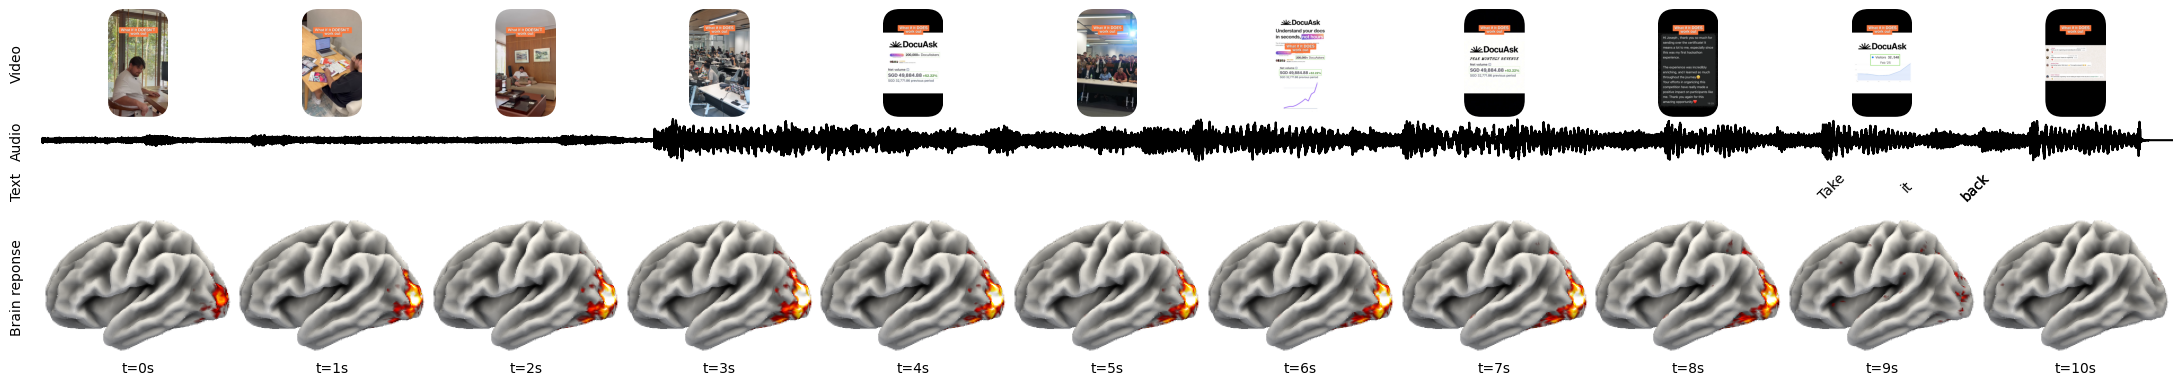

In [11]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [12]:
import numpy as np
import pandas as pd

n_seconds = preds.shape[0]
table = pd.DataFrame({
    "Second": range(n_seconds),
    "Mean Activation": preds.mean(axis=1),
    "Peak Activation": preds.max(axis=1),
})
print(table.to_string(index=False))

 Second  Mean Activation  Peak Activation
      0         0.015668         0.707335
      1         0.017669         0.987944
      2         0.024552         1.070664
      3         0.045174         1.096135
      4         0.044954         1.046614
      5         0.043140         1.005482
      6         0.036514         0.972778
      7         0.029145         0.996656
      8         0.034092         0.920782
      9         0.067899         0.570424
     10         0.046155         0.594748


In [17]:
from tribev2.plotting import PlotBrain

plotter = PlotBrain(mesh="fsaverage5", atlas_name="schaefer_2018", atlas_dim=400)

# Verify
print("atlas_name:", plotter.atlas_name)
print("atlas_dim:", plotter.atlas_dim)

# Load atlas
atlas = plotter.get_atlas()
print("Atlas type:", type(atlas))
print("Atlas attributes:", [a for a in dir(atlas) if not a.startswith('_')][:20])

atlas_name: schaefer_2018
atlas_dim: 400


[fetch_atlas_schaefer_2018] Added README.md to /root/nilearn_data

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_7Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.
nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

Atlas type: <class 'nilearn.datasets.atlas.Atlas'>
Atlas attributes: ['atlas_type', 'description', 'labels', 'lut', 'maps', 'template']


In [22]:
import numpy as np
from scipy.stats import pearsonr
from nilearn import datasets
from nilearn.surface import vol_to_surf

# Fetch fsaverage5 surface meshes
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

# Get Schaefer atlas volume
atlas = plotter.get_atlas()
atlas_img = atlas.maps

# Project volume atlas → surface labels (one label per vertex)
left_labels = vol_to_surf(
    atlas_img,
    fsaverage.pial_left,
    interpolation='nearest_most_frequent',
    radius=3,
).astype(int)

right_labels = vol_to_surf(
    atlas_img,
    fsaverage.pial_right,
    interpolation='nearest_most_frequent',
    radius=3,
).astype(int)

# Concatenate: fsaverage5 preds are ordered [left | right] (10242 + 10242 = 20484)
surf_labels = np.concatenate([left_labels, right_labels])
print(f"Surface labels shape: {surf_labels.shape}")
print(f"Preds shape: {preds.shape}")
print(f"Unique labels found: {len(np.unique(surf_labels))}")
print(f"Label range: {surf_labels.min()} to {surf_labels.max()}")

# Aggregate vertex preds → ROI preds by label
unique_labels = np.unique(surf_labels)
unique_labels = unique_labels[unique_labels > 0]  # drop background (label 0)

roi_activations = np.zeros((preds.shape[0], len(unique_labels)))
for i, lbl in enumerate(unique_labels):
    mask = surf_labels == lbl
    if mask.sum() > 0:
        roi_activations[:, i] = preds[:, mask].mean(axis=1)

print(f"ROI activations shape: {roi_activations.shape}")

# Atlas label strings
labels_text = [l.decode() if isinstance(l, bytes) else str(l) for l in atlas.labels]
print(f"First 5 atlas labels: {labels_text[:5]}")

# Build label_id → column_index mapping
def find_network_cols(keyword):
    """Find roi_activations column indices whose atlas label contains the keyword."""
    cols = []
    for col_idx, lbl_id in enumerate(unique_labels):
        if lbl_id < len(labels_text):
            lbl_text = labels_text[lbl_id]
            if keyword.lower() in lbl_text.lower():
                cols.append(col_idx)
    return cols

networks = {
    'Visual':      find_network_cols('Vis'),
    'Somatomotor': find_network_cols('SomMot'),
    'DorsAttn':    find_network_cols('DorsAttn'),
    'SalVentAttn': find_network_cols('SalVentAttn'),
    'Limbic':      find_network_cols('Limbic'),
    'Control':     find_network_cols('Cont'),
    'Default':     find_network_cols('Default'),
}

print("\n=== NETWORK ROI COUNTS ===")
for name, cols in networks.items():
    print(f"  {name:>15}: {len(cols)} regions")

# Per-second network time courses
print("\n=== NETWORK TIME COURSES ===")
net_names = list(networks.keys())
print("sec | " + " | ".join(f"{n[:10]:>10}" for n in net_names))
print("-" * 100)
for t in range(roi_activations.shape[0]):
    row = f"{t:>3} | "
    for name in net_names:
        cols = networks[name]
        val = roi_activations[t, cols].mean() if cols else np.nan
        row += f"{val:>10.4f} | "
    print(row)

# Cross-modal coherence: visual cortex vs somatomotor (auditory proxy in 7-net Schaefer)
if networks['Visual'] and networks['Somatomotor']:
    vis_tc = roi_activations[:, networks['Visual']].mean(axis=1)
    aud_tc = roi_activations[:, networks['Somatomotor']].mean(axis=1)
    r, p = pearsonr(vis_tc, aud_tc)
    print(f"\n=== CROSS-MODAL COHERENCE ===")
    print(f"Visual vs SomMot: r={r:.3f}, p={p:.4f}")
    print(f"  → high positive r: coherent multimodal processing")
    print(f"  → near zero: independent")
    print(f"  → negative: competing for attention")

Surface labels shape: (20484,)
Preds shape: (11, 20484)
Unique labels found: 401
Label range: 0 to 400
ROI activations shape: (11, 400)
First 5 atlas labels: ['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4']

=== NETWORK ROI COUNTS ===
           Visual: 61 regions
      Somatomotor: 77 regions
         DorsAttn: 46 regions
      SalVentAttn: 47 regions
           Limbic: 26 regions
          Control: 52 regions
          Default: 91 regions

=== NETWORK TIME COURSES ===
sec |     Visual | Somatomoto |   DorsAttn | SalVentAtt |     Limbic |    Control |    Default
----------------------------------------------------------------------------------------------------
  0 |     0.1846 |    -0.0290 |     0.0306 |    -0.0061 |    -0.0222 |    -0.0146 |    -0.0285 | 
  1 |     0.2809 |    -0.0374 |     0.0152 |    -0.0351 |    -0.0218 |    -0.0404 |    -0.0468 | 
  2 |     0.3344 |    -0.0377 |     0.0141 |    -0.0351 |    -0.0200 |    -0.04

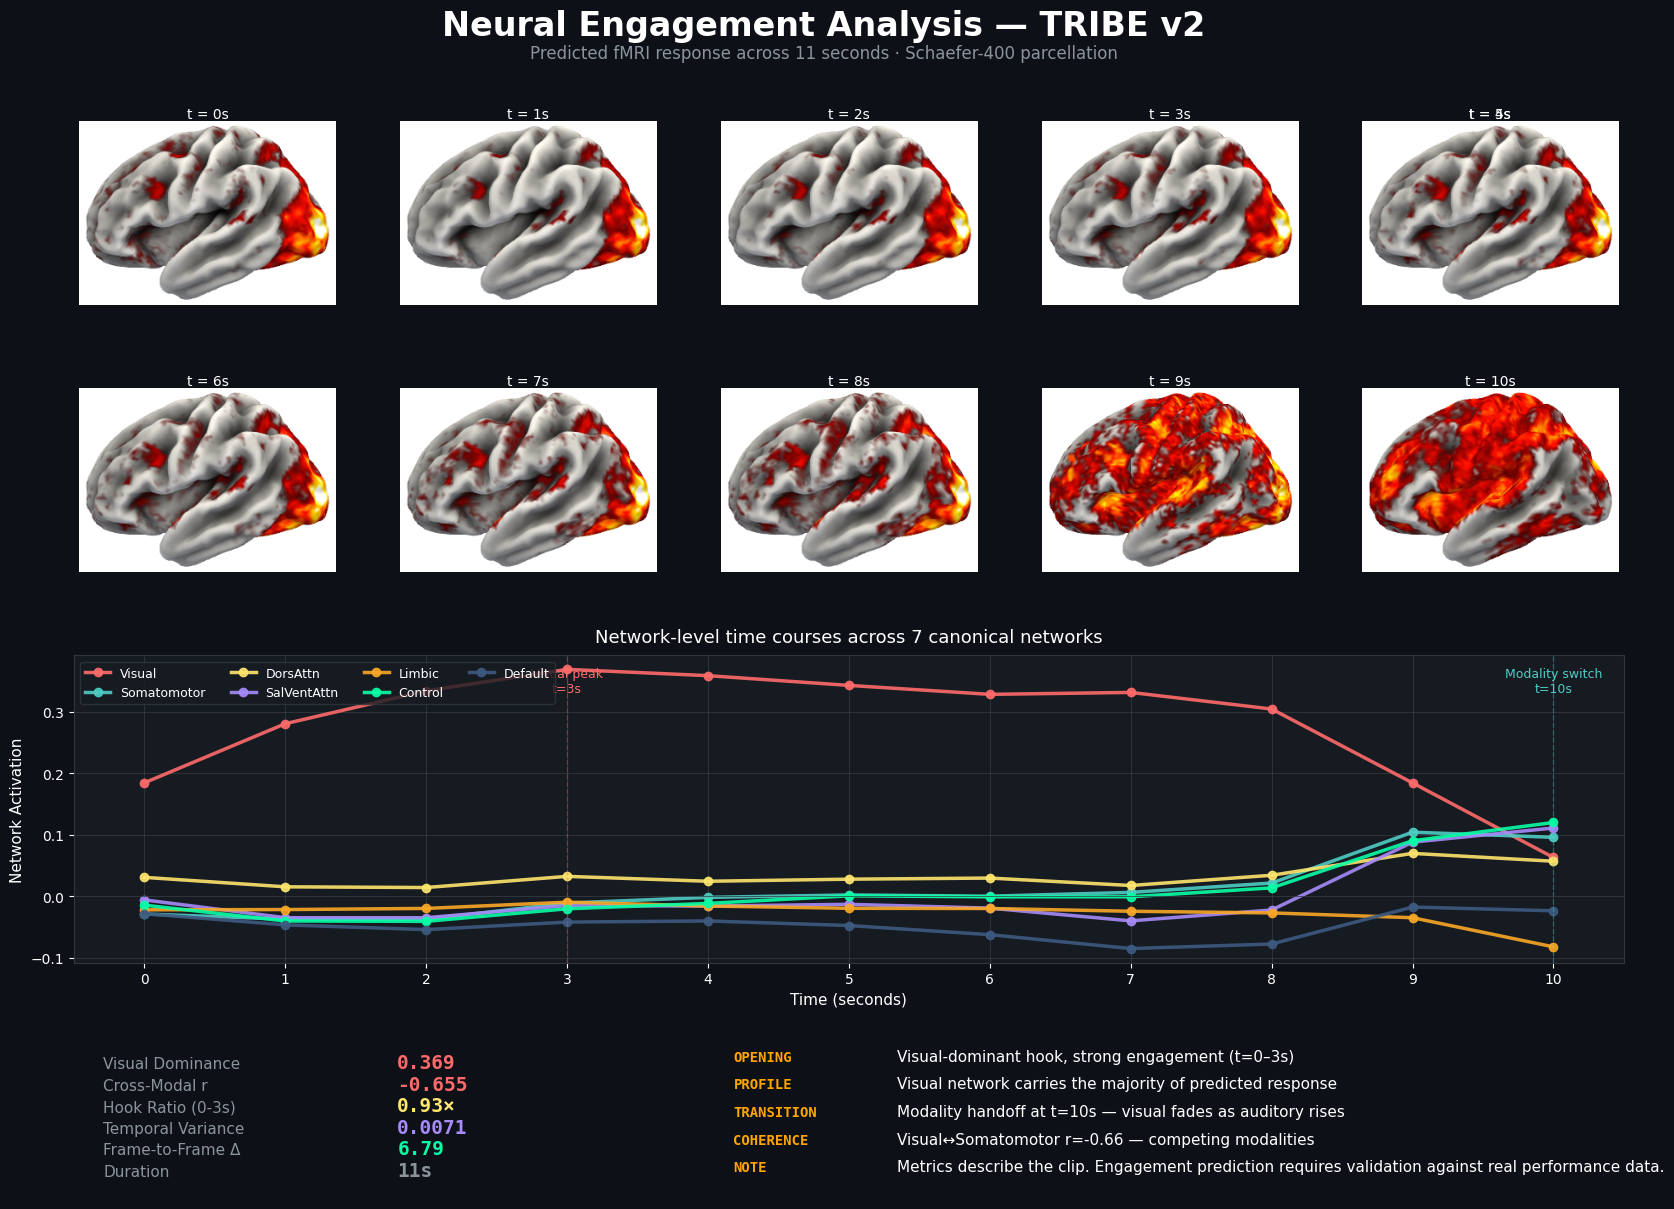


Saved: neural_engagement_dashboard.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from scipy.stats import pearsonr

# Assumes roi_activations, networks, preds, segments already computed
# from your last successful run

# === Build the figure ===
n_sec = roi_activations.shape[0]
fig = plt.figure(figsize=(20, 14), facecolor='#0d1117')

gs = GridSpec(4, 5, figure=fig,
              height_ratios=[1.2, 1.2, 2, 1],
              width_ratios=[1, 1, 1, 1, 1],
              hspace=0.4, wspace=0.2)

# --- Title bar ---
fig.suptitle('Neural Engagement Analysis — TRIBE v2',
             fontsize=24, color='white', fontweight='bold', y=0.96)
fig.text(0.5, 0.925, f'Predicted fMRI response across {n_sec} seconds · Schaefer-400 parcellation',
         ha='center', color='#8b949e', fontsize=12)

# --- Brain panels row (top two rows, spread across seconds) ---
# We'll place 11 brain plots across the top in 2 rows
brain_cols = 6  # 6 per row
brain_rows = 2
brain_axes = []
for i in range(n_sec):
    row = i // brain_cols
    col = i % brain_cols
    ax = fig.add_subplot(gs[row, col] if col < 5 else gs[row, 4])
    # Plot single-timestep brain (left hemisphere)
    try:
        plotter.plot_surf(preds[i], axes=ax, views='left',
                          cmap='fire', norm_percentile=99,
                          vmin=0.3, alpha_cmap=(0, 0.2))
    except Exception as e:
        ax.text(0.5, 0.5, f't={i}s', ha='center', va='center', color='white')
    ax.set_title(f't = {i}s', color='white', fontsize=10, pad=2)
    ax.axis('off')
    ax.set_facecolor('#0d1117')
    brain_axes.append(ax)

# --- Network time-course stacked lines (row 2) ---
ax_net = fig.add_subplot(gs[2, :])
ax_net.set_facecolor('#161b22')

# Color palette — distinct for each network
net_colors = {
    'Visual':      '#ff6b6b',
    'Somatomotor': '#4ecdc4',
    'DorsAttn':    '#ffe66d',
    'SalVentAttn': '#a78bfa',
    'Limbic':      '#f9a826',
    'Control':     '#06ffa5',
    'Default':     '#3d5a80',
}

time_axis = np.arange(n_sec)
for name, cols in networks.items():
    if not cols:
        continue
    tc = roi_activations[:, cols].mean(axis=1)
    ax_net.plot(time_axis, tc,
                label=name,
                color=net_colors.get(name, 'white'),
                linewidth=2.5,
                marker='o',
                markersize=6,
                alpha=0.9)

# Highlight the transition moment
visual_tc = roi_activations[:, networks['Visual']].mean(axis=1)
peak_visual = np.argmax(visual_tc)
transition = np.argmax(np.abs(np.diff(visual_tc)))

ax_net.axvline(peak_visual, color='#ff6b6b', linestyle='--', alpha=0.3, linewidth=1)
ax_net.axvline(transition + 1, color='#4ecdc4', linestyle='--', alpha=0.3, linewidth=1)
ax_net.text(peak_visual, ax_net.get_ylim()[1] * 0.95 if ax_net.get_ylim()[1] > 0 else 0.4,
            f'Visual peak\nt={peak_visual}s',
            color='#ff6b6b', fontsize=9, ha='center', va='top')
ax_net.text(transition + 1, ax_net.get_ylim()[1] * 0.95 if ax_net.get_ylim()[1] > 0 else 0.4,
            f'Modality switch\nt={transition+1}s',
            color='#4ecdc4', fontsize=9, ha='center', va='top')

ax_net.axhline(0, color='#30363d', linewidth=0.5)
ax_net.set_xlabel('Time (seconds)', color='white', fontsize=11)
ax_net.set_ylabel('Network Activation', color='white', fontsize=11)
ax_net.set_title('Network-level time courses across 7 canonical networks',
                 color='white', fontsize=13, pad=10)
ax_net.legend(loc='upper left', ncol=4, facecolor='#161b22',
              edgecolor='#30363d', labelcolor='white', fontsize=9)
ax_net.tick_params(colors='white')
for spine in ax_net.spines.values():
    spine.set_color('#30363d')
ax_net.grid(True, alpha=0.1, color='white')
ax_net.set_xticks(time_axis)

# --- Metrics card (row 3, left 2 cols) ---
ax_metrics = fig.add_subplot(gs[3, :2])
ax_metrics.set_facecolor('#161b22')
ax_metrics.axis('off')

# Compute metrics
r, p = pearsonr(visual_tc, roi_activations[:, networks['Somatomotor']].mean(axis=1))
hook_ratio = visual_tc[:3].mean() / visual_tc[3:].mean() if visual_tc[3:].mean() > 0 else float('nan')
temporal_var = preds.var(axis=0).mean()
f2f_change = np.linalg.norm(np.diff(preds, axis=0), axis=1).mean()

metrics_text = [
    ('Visual Dominance',   f'{visual_tc.max():.3f}',   '#ff6b6b'),
    ('Cross-Modal r',      f'{r:+.3f}',                 '#4ecdc4' if r > 0 else '#ff6b6b'),
    ('Hook Ratio (0-3s)',  f'{hook_ratio:.2f}×',        '#ffe66d'),
    ('Temporal Variance',  f'{temporal_var:.4f}',       '#a78bfa'),
    ('Frame-to-Frame Δ',   f'{f2f_change:.2f}',         '#06ffa5'),
    ('Duration',           f'{n_sec}s',                 '#8b949e'),
]

for i, (label, value, color) in enumerate(metrics_text):
    y = 0.85 - i * 0.14
    ax_metrics.text(0.05, y, label, color='#8b949e', fontsize=11,
                    transform=ax_metrics.transAxes, fontweight='normal')
    ax_metrics.text(0.55, y, value, color=color, fontsize=14,
                    transform=ax_metrics.transAxes, fontweight='bold',
                    family='monospace')

# --- Interpretation card (row 3, right 3 cols) ---
ax_interp = fig.add_subplot(gs[3, 2:])
ax_interp.set_facecolor('#161b22')
ax_interp.axis('off')

# Auto-generate interpretation from data
dominant_net = max(networks.keys(), key=lambda n: roi_activations[:, networks[n]].mean() if networks[n] else -np.inf)
opening_strength = 'strong' if visual_tc[:3].mean() > 0.2 else 'moderate' if visual_tc[:3].mean() > 0.05 else 'soft'
coherence_verdict = 'competing modalities' if r < -0.3 else 'coherent' if r > 0.3 else 'independent'

interp_lines = [
    ('OPENING', f'Visual-dominant hook, {opening_strength} engagement (t=0–3s)'),
    ('PROFILE', f'{dominant_net} network carries the majority of predicted response'),
    ('TRANSITION', f'Modality handoff at t={transition+1}s — visual fades as auditory rises'),
    ('COHERENCE', f'Visual↔Somatomotor r={r:+.2f} — {coherence_verdict}'),
    ('NOTE', 'Metrics describe the clip. Engagement prediction requires validation against real performance data.'),
]

for i, (label, text) in enumerate(interp_lines):
    y = 0.9 - i * 0.18
    ax_interp.text(0.02, y, label, color='#ffa500', fontsize=10,
                   fontweight='bold', family='monospace',
                   transform=ax_interp.transAxes)
    ax_interp.text(0.2, y, text, color='white', fontsize=11,
                   transform=ax_interp.transAxes)

plt.savefig('neural_engagement_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\nSaved: neural_engagement_dashboard.png")

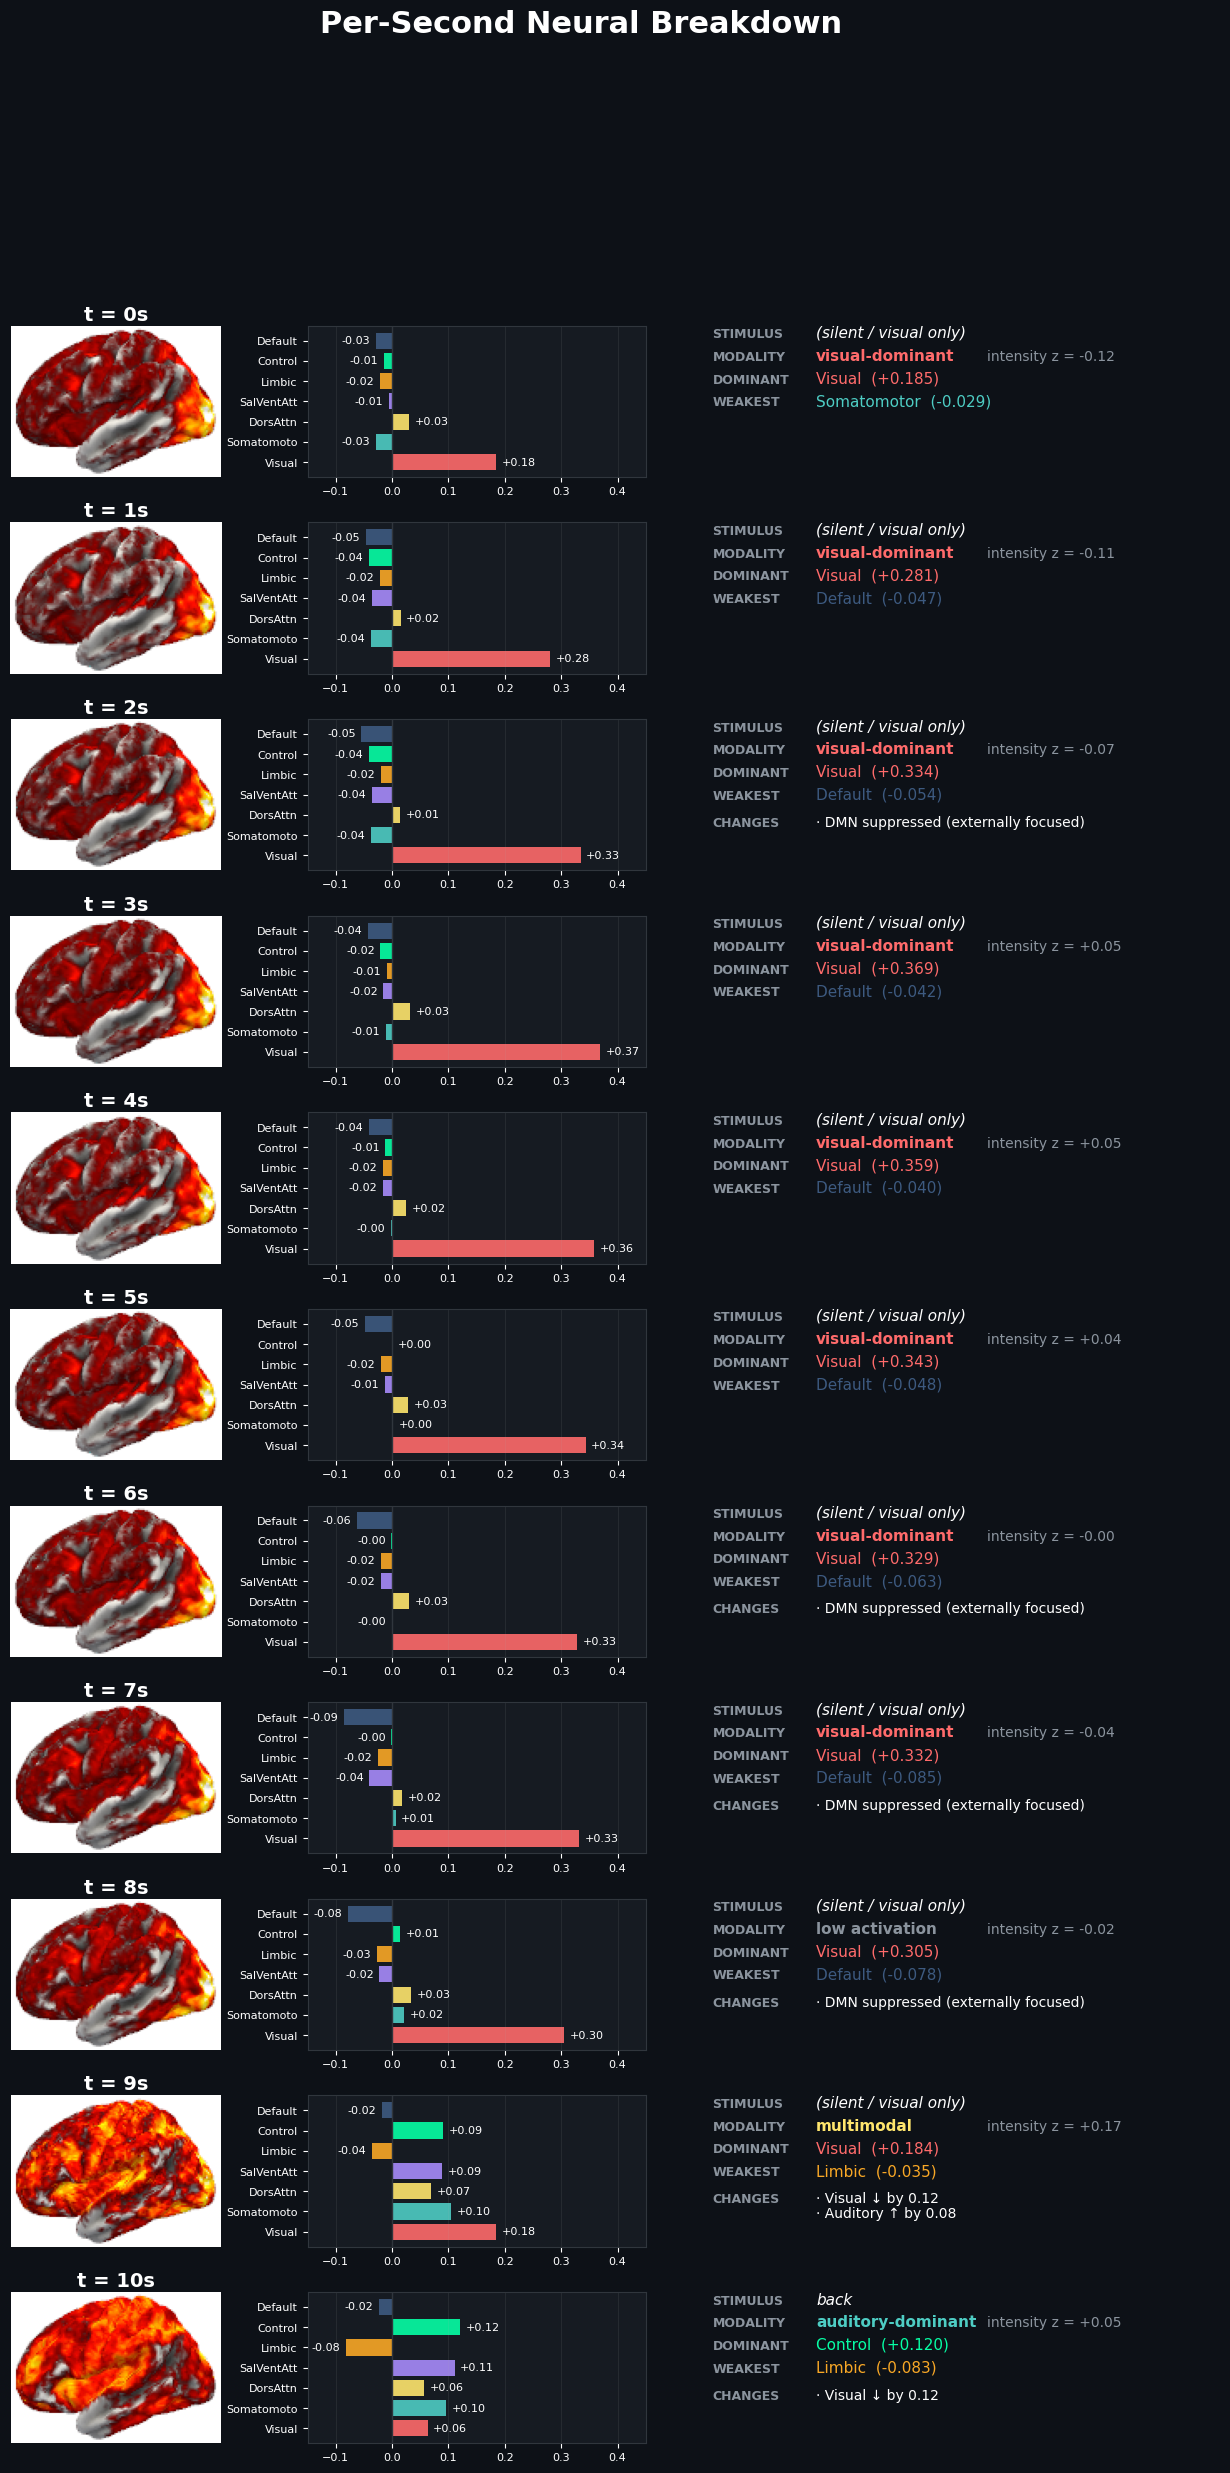


Saved: per_frame_breakdown.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import pearsonr

# === Setup ===
n_sec = roi_activations.shape[0]

net_tcs = {name: roi_activations[:, cols].mean(axis=1) if cols else np.zeros(n_sec)
           for name, cols in networks.items()}
visual_tc = net_tcs['Visual']
sommot_tc = net_tcs['Somatomotor']
default_tc = net_tcs['Default']

baseline_mean = preds.mean()
baseline_std = preds.std()

def events_at_second(t, df):
    active = df[(df['start'] <= t) & (df['start'] + df['duration'] >= t)]
    return active[active['type'] == 'Word']['text'].dropna().tolist()

try:
    events_df = df
except NameError:
    events_df = None

# Network colors (match the dashboard)
net_colors = {
    'Visual': '#ff6b6b', 'Somatomotor': '#4ecdc4', 'DorsAttn': '#ffe66d',
    'SalVentAttn': '#a78bfa', 'Limbic': '#f9a826', 'Control': '#06ffa5',
    'Default': '#3d5a80',
}

# === Figure: one row per second ===
fig = plt.figure(figsize=(16, 2.5 * n_sec), facecolor='#0d1117')
gs = GridSpec(n_sec, 3, figure=fig, width_ratios=[1.2, 1.5, 2.3],
              hspace=0.3, wspace=0.15)

fig.suptitle('Per-Second Neural Breakdown',
             fontsize=22, color='white', fontweight='bold', y=0.995)

for t in range(n_sec):
    # --- Column 1: Brain image ---
    ax_brain = fig.add_subplot(gs[t, 0])
    try:
        plotter.plot_surf(preds[t], axes=ax_brain, views='left',
                          cmap='fire', norm_percentile=99,
                          vmin=0.1, alpha_cmap=(0, 0.2))
    except Exception:
        ax_brain.text(0.5, 0.5, f't={t}s', ha='center', va='center',
                      color='white', fontsize=14)
    ax_brain.set_facecolor('#0d1117')
    ax_brain.axis('off')
    ax_brain.set_title(f't = {t}s', color='white', fontsize=14,
                       fontweight='bold', pad=4)

    # --- Column 2: Mini network bar chart ---
    ax_bars = fig.add_subplot(gs[t, 1])
    ax_bars.set_facecolor('#161b22')

    net_names = list(net_tcs.keys())
    vals = [net_tcs[n][t] for n in net_names]
    colors = [net_colors[n] for n in net_names]

    bars = ax_bars.barh(range(len(net_names)), vals, color=colors, alpha=0.9)
    ax_bars.axvline(0, color='#30363d', linewidth=1)
    ax_bars.set_yticks(range(len(net_names)))
    ax_bars.set_yticklabels([n[:10] for n in net_names], color='white', fontsize=9)
    ax_bars.tick_params(colors='white', labelsize=8)
    ax_bars.set_xlim(-0.15, 0.45)
    for spine in ax_bars.spines.values():
        spine.set_color('#30363d')
    ax_bars.grid(True, axis='x', alpha=0.1)

    # Add value labels on bars
    for bar, v in zip(bars, vals):
        x_pos = v + (0.01 if v >= 0 else -0.01)
        ha = 'left' if v >= 0 else 'right'
        ax_bars.text(x_pos, bar.get_y() + bar.get_height()/2,
                     f'{v:+.2f}', va='center', ha=ha,
                     color='white', fontsize=8)

    # --- Column 3: Text breakdown ---
    ax_text = fig.add_subplot(gs[t, 2])
    ax_text.set_facecolor('#161b22')
    ax_text.axis('off')

    # Compute frame-specific interpretation
    net_vals = {n: net_tcs[n][t] for n in net_tcs}
    dominant = max(net_vals, key=net_vals.get)
    weakest = min(net_vals, key=net_vals.get)

    frame_mean = preds[t].mean()
    z = (frame_mean - baseline_mean) / baseline_std if baseline_std > 0 else 0

    words = events_at_second(t, events_df) if events_df is not None else []
    stimulus = ' '.join(words) if words else '(silent / visual only)'

    v, s = visual_tc[t], sommot_tc[t]
    if v > 0.15 and s < 0.02:
        modality = 'visual-dominant'
        mod_color = '#ff6b6b'
    elif s > 0.05 and v < 0.15:
        modality = 'auditory-dominant'
        mod_color = '#4ecdc4'
    elif v > 0.1 and s > 0.05:
        modality = 'multimodal'
        mod_color = '#ffe66d'
    else:
        modality = 'low activation'
        mod_color = '#8b949e'

    # Observations
    observations = []
    if t > 0:
        dv = visual_tc[t] - visual_tc[t-1]
        ds = sommot_tc[t] - sommot_tc[t-1]
        if abs(dv) > 0.1:
            arrow = '↑' if dv > 0 else '↓'
            observations.append(f"Visual {arrow} by {abs(dv):.2f}")
        if abs(ds) > 0.05:
            arrow = '↑' if ds > 0 else '↓'
            observations.append(f"Auditory {arrow} by {abs(ds):.2f}")

    if default_tc[t] < -0.05:
        observations.append("DMN suppressed (externally focused)")
    elif default_tc[t] > 0.02:
        observations.append("DMN engaged (self-referential)")

    # Layout text
    y = 0.92
    ax_text.text(0.02, y, f"STIMULUS", color='#8b949e',
                 fontsize=9, fontweight='bold', transform=ax_text.transAxes)
    ax_text.text(0.22, y, stimulus, color='white',
                 fontsize=11, transform=ax_text.transAxes, style='italic')
    y -= 0.15

    ax_text.text(0.02, y, f"MODALITY", color='#8b949e',
                 fontsize=9, fontweight='bold', transform=ax_text.transAxes)
    ax_text.text(0.22, y, modality, color=mod_color,
                 fontsize=11, fontweight='bold', transform=ax_text.transAxes)
    ax_text.text(0.55, y, f"intensity z = {z:+.2f}", color='#8b949e',
                 fontsize=10, transform=ax_text.transAxes)
    y -= 0.15

    ax_text.text(0.02, y, f"DOMINANT", color='#8b949e',
                 fontsize=9, fontweight='bold', transform=ax_text.transAxes)
    ax_text.text(0.22, y, f"{dominant}  ({net_vals[dominant]:+.3f})",
                 color=net_colors[dominant], fontsize=11,
                 transform=ax_text.transAxes)
    y -= 0.15

    ax_text.text(0.02, y, f"WEAKEST", color='#8b949e',
                 fontsize=9, fontweight='bold', transform=ax_text.transAxes)
    ax_text.text(0.22, y, f"{weakest}  ({net_vals[weakest]:+.3f})",
                 color=net_colors[weakest], fontsize=11,
                 transform=ax_text.transAxes)
    y -= 0.18

    if observations:
        ax_text.text(0.02, y, "CHANGES", color='#8b949e',
                     fontsize=9, fontweight='bold', transform=ax_text.transAxes)
        for obs in observations:
            ax_text.text(0.22, y, f"· {obs}", color='white',
                         fontsize=10, transform=ax_text.transAxes)
            y -= 0.1

plt.savefig('per_frame_breakdown.png', dpi=130,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\nSaved: per_frame_breakdown.png")